# Bike Sharing Demand — Dataset Analysis

Source: UCI Bike Sharing Dataset — hourly bike rental records with weather, calendar, and time variables.

This notebook studies the Bike Sharing dataset as a real-world benchmark for testing the limitations of ZZU transformations. Unlike the concrete strength dataset, where the target is governed by a smoother physical relationship, bike rental demand is strongly affected by regime-switching behavior: commuting hours versus nighttime, weekdays versus weekends, seasons, holidays, and weather conditions.

This makes the dataset a useful case where a single global response transformation may fail. In particular, ZZU may struggle because transformed OLS screening assumes that some transformation of the response can be explained well by a global linear structure, while bike demand is interaction-heavy and piecewise.

Block 1 — Summary statistics and targeted visualizations to characterize the dataset.

Block 2 — Preprocessing pipeline: quality checks, feature engineering, train/test split, and artifacts saved for ZZU and baseline methods.

Block 3 — ZZU and baseline comparison on the Bike Sharing dataset.

Block 4 -- Interpretation of the results.

Dataset : 17379 rows x 17 columns
Missing : 0
Duplicates: 0

Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

         instant     season         yr       mnth         hr    holiday    weekday  workingday  weathersit       temp      atemp        hum  windspeed     casual  registered        cnt
count  17379.000  17379.000  17379.000  17379.000  17379.000  17379.000  17379.000   17379.000   17379.000  17379.000  17379.000  17379.000  17379.000  17379.000   17379.000  17379.000
mean    8690.000      2.502      0.503      6.538     11.547      0.029      3.004       0.683       1.425      0.497      0.476      0.627      0.190     35.676     153.787    189.463
std     5017.029      1.107      0.500      3.439      6.914      0.167      2.006       0.465       0.639      0.193      0.172      0.193      0.122     49.305     151.357    181.388
min        1.000   

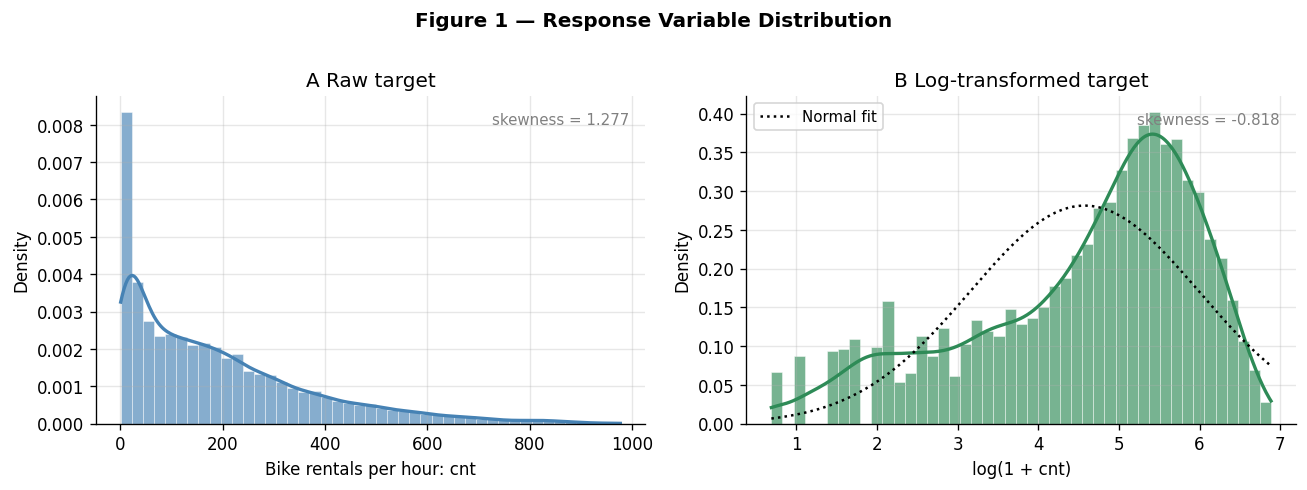

Count range : 1 to 977 rentals/hour
Skewness    : raw = 1.277, log1p-transformed = -0.818
-> log1p reduces skewness, but the target remains shaped by time-of-day and regime effects.
   This is a warning sign that one global response transformation may not be enough.


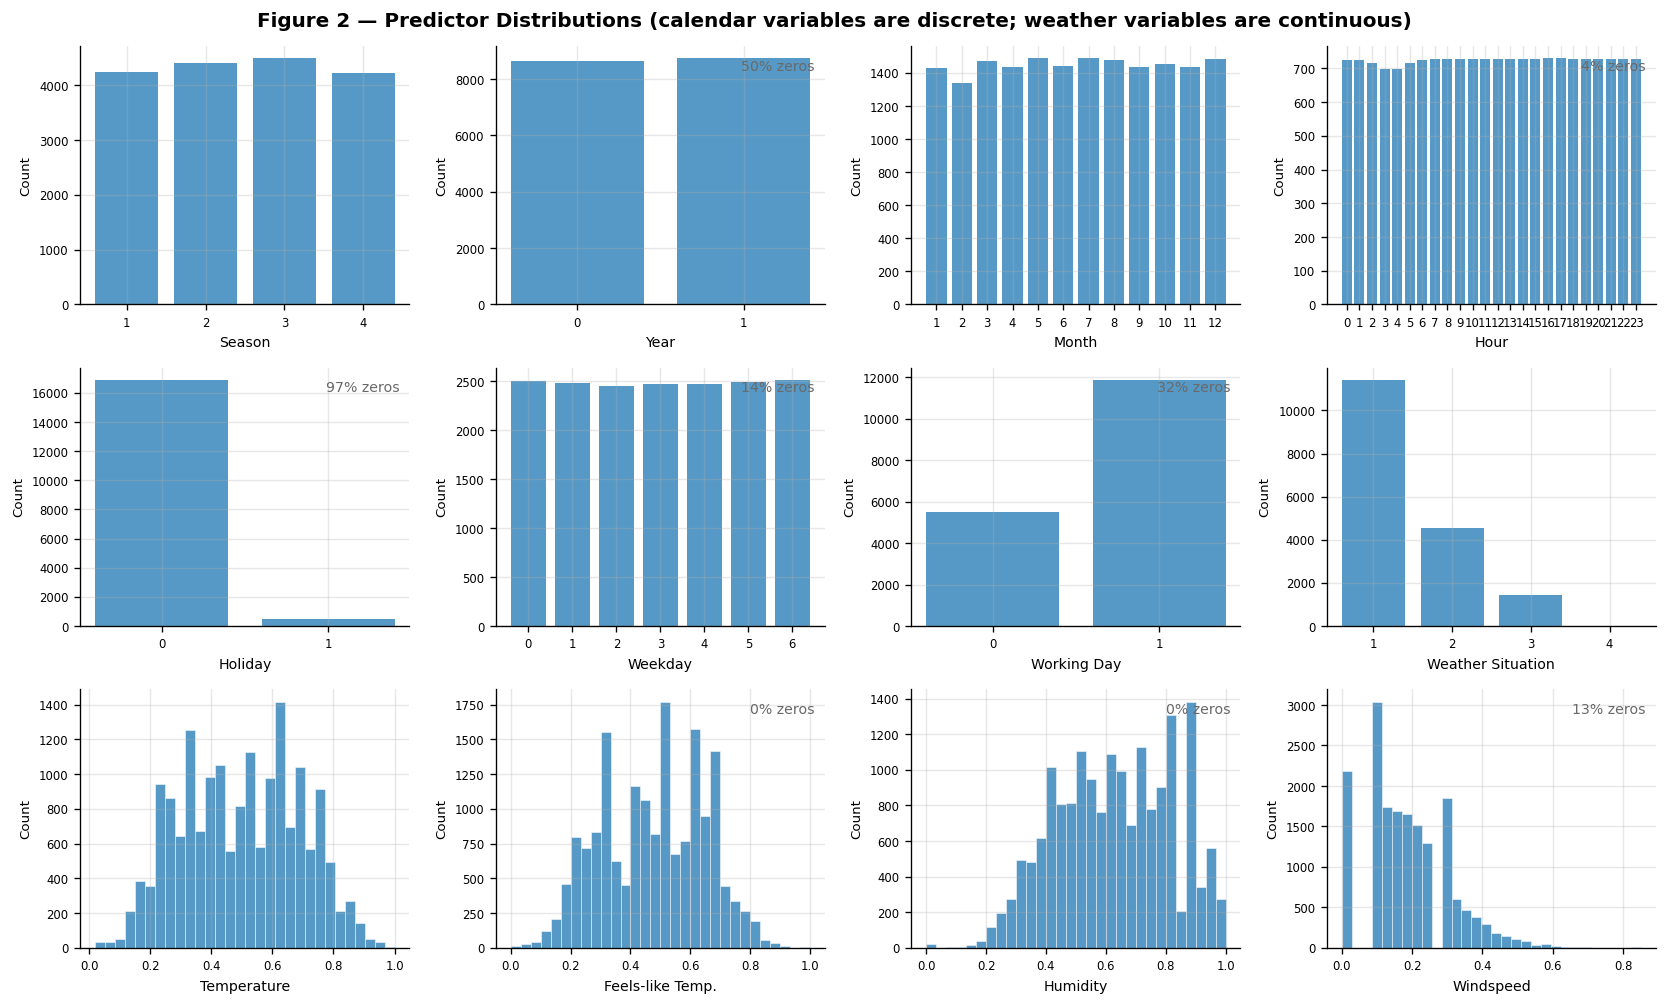

Important structure:
 1. hr, weekday, workingday, season, and weathersit are discrete regime variables.
 2. temp, hum, and windspeed are continuous weather variables.
 3. Bike demand is likely driven by interactions such as hr × workingday and hr × temp.


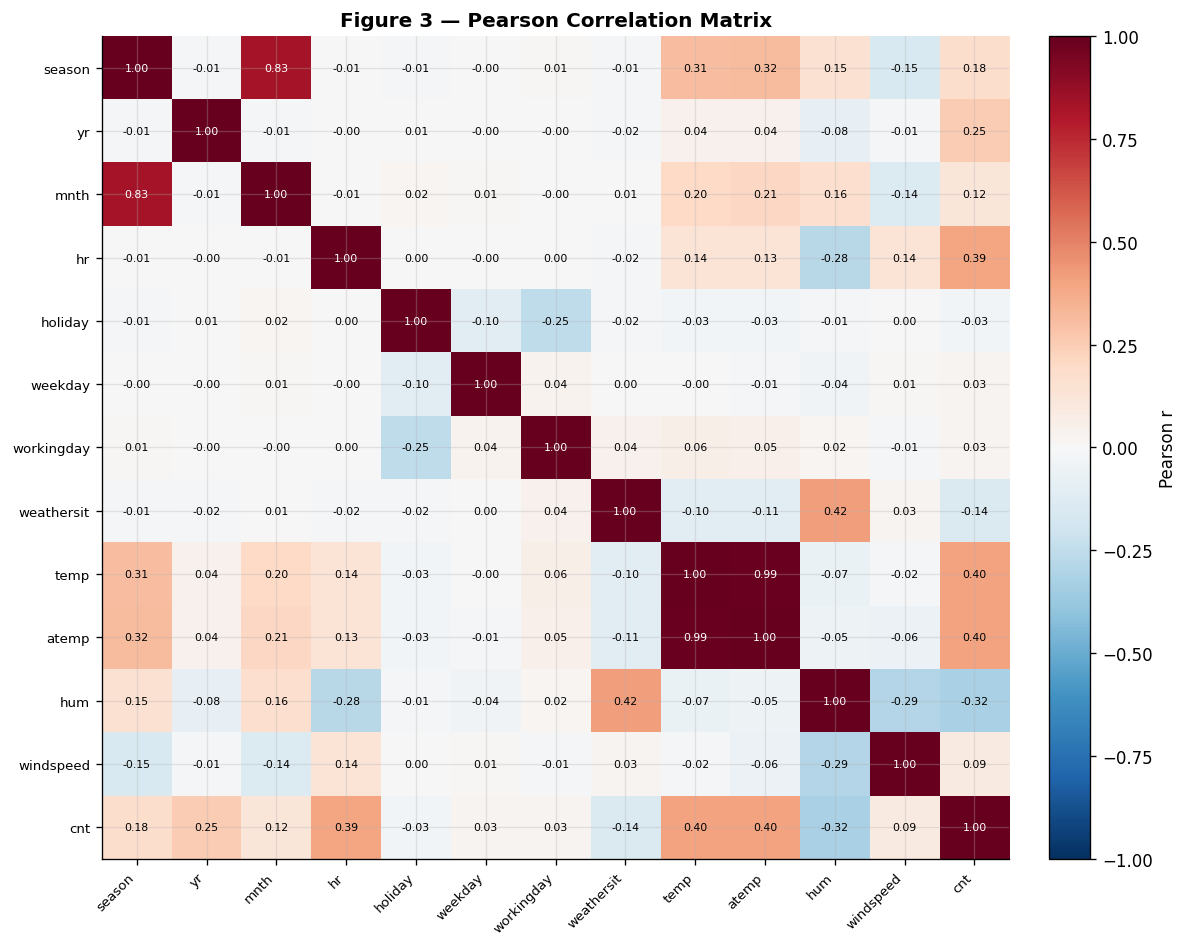

Correlation with bike rental count cnt (ranked):
 temp           +0.405 ||||||||
 atemp          +0.401 ||||||||
 hr             +0.394 |||||||
 hum            -0.323 ||||||
 yr             +0.250 |||||
 season         +0.178 |||
 weathersit     -0.142 ||
 mnth           +0.121 ||
 windspeed      +0.093 |
 holiday        -0.031 
 workingday     +0.030 
 weekday        +0.027 


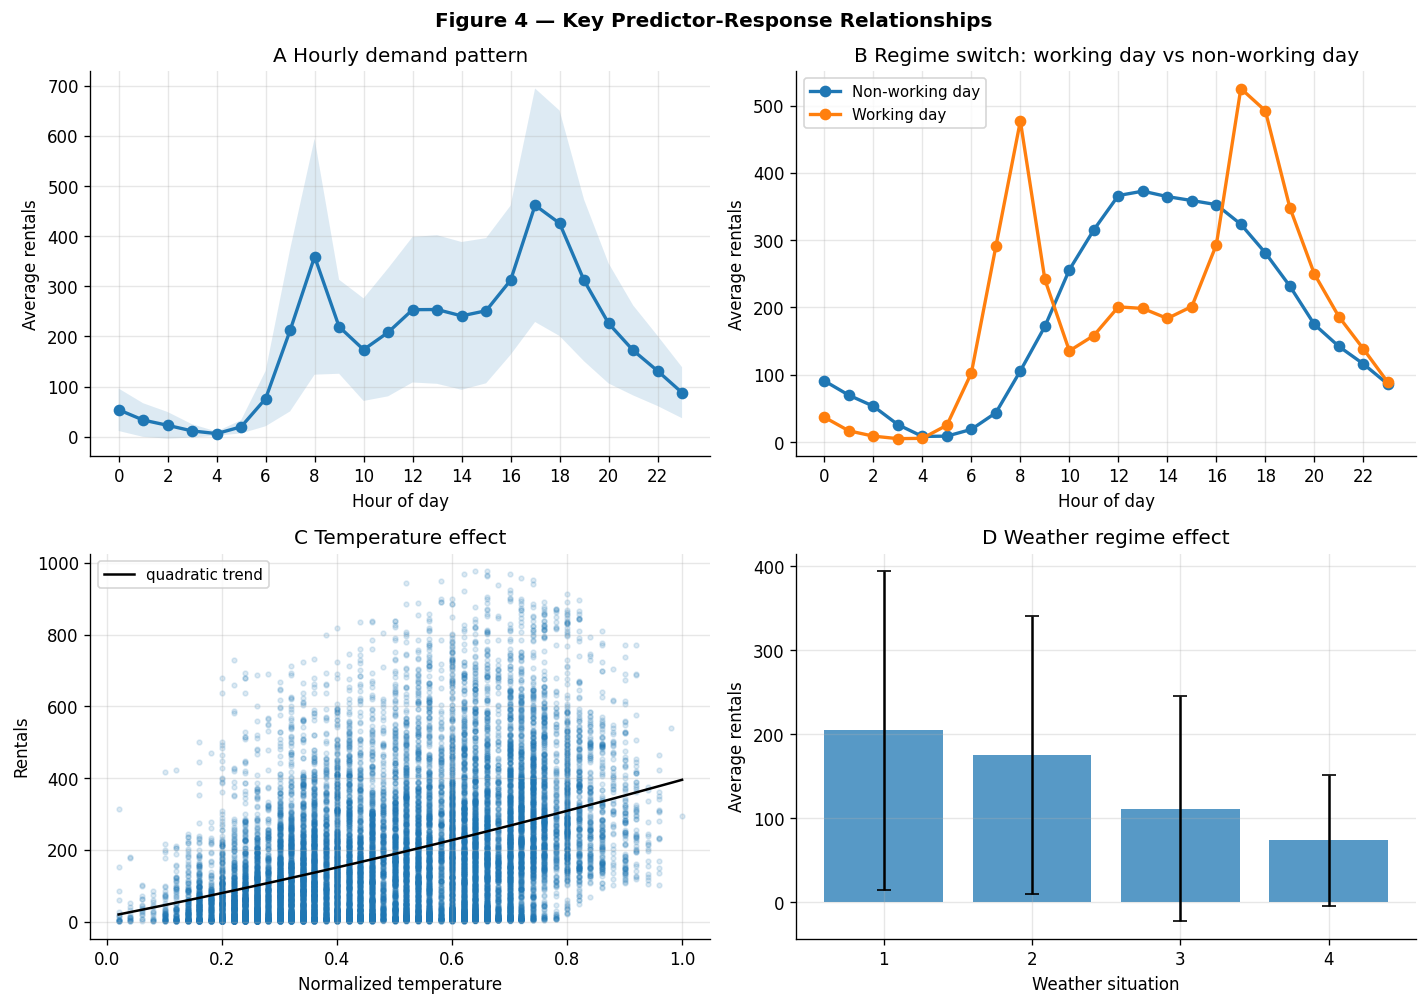

Takeaways for model_fn design:
 1. Hour has a strong nonlinear, multi-peak relationship with demand.
 2. Workingday changes the shape of the hourly demand curve, especially during commute hours.
 3. Temperature has a nonlinear effect, but it is not enough to explain demand globally.
 4. Weather and calendar variables create regime-switching behavior.
 5. This is a strong candidate dataset where ZZU may fail because no single global transformation captures all interactions.


In [2]:
# ================================================================
# BLOCK 1 — Dataset Exploration
# ================================================================

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Use hourly data because it contains the strongest regime-switching structure.
df = pd.read_csv('bike+sharing+dataset/hour.csv')

TARGET = 'cnt'

FEATURES = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
    'weathersit', 'temp', 'atemp', 'hum', 'windspeed'
]

LEAKAGE_COLS = ['casual', 'registered']
DROP_COLS = ['instant', 'dteday'] + LEAKAGE_COLS

y = df[TARGET].values

# ---- printed summary ----
print(f'Dataset : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Missing : {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print()
print('Columns:')
print(df.columns.tolist())
print()
print(df.describe().round(3).to_string())
print()

print('Leakage warning:')
print(' casual + registered = cnt, so casual and registered must NOT be used as predictors.')
print(f' Check: all(casual + registered == cnt) = {np.all(df["casual"] + df["registered"] == df["cnt"])}')
print()

# ---- zero / categorical summaries ----
print('Zero-valued entries per candidate predictor:')
for c in FEATURES:
    p = (df[c] == 0).mean() * 100
    bar = '|' * int(p / 2)
    tag = ' <- many zeros / indicator-like' if p > 10 else ''
    print(f' {c:<14} {p:5.1f}% {bar}{tag}')

print()
print('Categorical / discrete variable levels:')
for c in ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']:
    vals = sorted(df[c].unique())
    print(f' {c:<12}: {vals}')

# ---- KDE helper (Silverman bandwidth, vectorised) ----
def kde(data, xg, bw=None):
    d = np.asarray(data, float)
    if bw is None:
        bw = 1.06 * d.std() * len(d) ** (-0.2)
        if bw <= 0:
            bw = 1.0
    u = (xg[:, None] - d[None, :]) / bw
    return np.mean(np.exp(-0.5 * u ** 2), axis=1) / (bw * np.sqrt(2 * np.pi))

# ================================================================
# Figure 1 — Response variable distribution
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, xlabel, color, title in [
    (axes[0], y, 'Bike rentals per hour: cnt', 'steelblue', 'A Raw target'),
    (axes[1], np.log1p(y), 'log(1 + cnt)', 'seagreen', 'B Log-transformed target'),
]:
    ax.hist(data, bins=45, density=True, color=color, alpha=0.65,
            edgecolor='white', linewidth=0.4)

    xg = np.linspace(data.min(), data.max(), 300)
    ax.plot(xg, kde(data, xg), color=color, lw=2)

    if color == 'seagreen':
        mu, sigma = data.mean(), data.std()
        ax.plot(
            xg,
            np.exp(-0.5 * ((xg - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)),
            'k:', lw=1.5, label='Normal fit'
        )
        ax.legend(fontsize=9)

    sk = float(pd.Series(data).skew())
    ax.text(0.97, 0.95, f'skewness = {sk:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(title)

fig.suptitle('Figure 1 — Response Variable Distribution', fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

print(f'Count range : {y.min():.0f} to {y.max():.0f} rentals/hour')
print(f'Skewness    : raw = {float(pd.Series(y).skew()):.3f}, '
      f'log1p-transformed = {float(pd.Series(np.log1p(y)).skew()):.3f}')
print('-> log1p reduces skewness, but the target remains shaped by time-of-day and regime effects.')
print('   This is a warning sign that one global response transformation may not be enough.')

# ================================================================
# Figure 2 — Predictor distributions
# ================================================================

FEAT_LABELS = [
    'Season', 'Year', 'Month', 'Hour', 'Holiday', 'Weekday', 'Working Day',
    'Weather Situation', 'Temperature', 'Feels-like Temp.', 'Humidity', 'Windspeed'
]

fig, axes = plt.subplots(3, 4, figsize=(14, 8.5))

for ax, col, label in zip(axes.flat, FEATURES, FEAT_LABELS):
    data = df[col].values

    if col in ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']:
        vals, counts = np.unique(data, return_counts=True)
        ax.bar(vals, counts, alpha=0.75)
        ax.set_xticks(vals)
    else:
        ax.hist(data, bins=30, alpha=0.75, edgecolor='white', linewidth=0.4)

    pct_z = (data == 0).mean() * 100
    if pct_z > 0:
        ax.text(0.97, 0.95, f'{pct_z:.0f}% zeros', transform=ax.transAxes,
                ha='right', va='top', fontsize=8.5, color='dimgray')

    ax.set_xlabel(label, fontsize=8.5)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle(
    'Figure 2 — Predictor Distributions '
    '(calendar variables are discrete; weather variables are continuous)',
    fontweight='bold'
)
fig.tight_layout()
plt.show()

print('Important structure:')
print(' 1. hr, weekday, workingday, season, and weathersit are discrete regime variables.')
print(' 2. temp, hum, and windspeed are continuous weather variables.')
print(' 3. Bike demand is likely driven by interactions such as hr × workingday and hr × temp.')

# ================================================================
# Figure 3 — Pearson correlation matrix
# ================================================================

corr_cols = FEATURES + [TARGET]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[corr_cols].corr()
labels = [c.replace('_', '\n') for c in corr.columns]
n = len(labels)

im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=8)

for i in range(n):
    for j in range(n):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=6.5, color='white' if abs(v) > 0.55 else 'black')

ax.set_title('Figure 3 — Pearson Correlation Matrix', fontweight='bold', fontsize=12)
fig.tight_layout()
plt.show()

tgt_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('Correlation with bike rental count cnt (ranked):')
for feat, val in tgt_corr.items():
    bar = '|' * int(abs(val) * 20)
    print(f' {feat:<14} {val:+.3f} {bar}')

# ================================================================
# Figure 4 — Key predictor-response relationships
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))

# A: Average rentals by hour
ax = axes[0, 0]
hour_mean = df.groupby('hr')[TARGET].mean()
hour_std = df.groupby('hr')[TARGET].std()
ax.plot(hour_mean.index, hour_mean.values, marker='o', lw=2)
ax.fill_between(hour_mean.index,
                hour_mean.values - hour_std.values,
                hour_mean.values + hour_std.values,
                alpha=0.15)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average rentals')
ax.set_title('A Hourly demand pattern')
ax.set_xticks(range(0, 24, 2))

# B: Hour by workingday interaction
ax = axes[0, 1]
for wd, label in [(0, 'Non-working day'), (1, 'Working day')]:
    m = df[df['workingday'] == wd].groupby('hr')[TARGET].mean()
    ax.plot(m.index, m.values, marker='o', lw=2, label=label)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average rentals')
ax.set_title('B Regime switch: working day vs non-working day')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)

# C: Temperature vs count
ax = axes[1, 0]
ax.scatter(df['temp'], y, alpha=0.15, s=8, rasterized=True)
tf = np.polyfit(df['temp'].values, y, 2)
xf = np.linspace(df['temp'].min(), df['temp'].max(), 200)
ax.plot(xf, np.polyval(tf, xf), 'k-', lw=1.5, label='quadratic trend')
ax.set_xlabel('Normalized temperature')
ax.set_ylabel('Rentals')
ax.set_title('C Temperature effect')
ax.legend(fontsize=9)

# D: Weather situation vs count
ax = axes[1, 1]
weather_means = df.groupby('weathersit')[TARGET].mean()
weather_stds = df.groupby('weathersit')[TARGET].std()
ax.bar(weather_means.index, weather_means.values, yerr=weather_stds.values,
       capsize=4, alpha=0.75)
ax.set_xlabel('Weather situation')
ax.set_ylabel('Average rentals')
ax.set_title('D Weather regime effect')
ax.set_xticks(weather_means.index)

fig.suptitle('Figure 4 — Key Predictor-Response Relationships', fontweight='bold')
fig.tight_layout()
plt.show()

print('Takeaways for model_fn design:')
print(' 1. Hour has a strong nonlinear, multi-peak relationship with demand.')
print(' 2. Workingday changes the shape of the hourly demand curve, especially during commute hours.')
print(' 3. Temperature has a nonlinear effect, but it is not enough to explain demand globally.')
print(' 4. Weather and calendar variables create regime-switching behavior.')
print(' 5. This is a strong candidate dataset where ZZU may fail because no single global transformation captures all interactions.')

## Block 2 — Preprocessing

Goals:

1. Verify data quality after the exploratory analysis.
2. Remove leakage columns (`casual`, `registered`) and non-predictive identifier/date columns.
3. Engineer features that expose the regime-switching structure of hourly bike demand:
   - cyclic hour, month, and weekday encodings;
   - rush-hour indicators;
   - workingday × rush-hour interactions;
   - weather and season dummy variables.
4. Define the final feature matrix used by ZZU and baseline methods.
5. Produce a reproducible 80/20 train/test split.
6. Save all preprocessing artifacts to `bike_split.npz`.

Unlike the concrete strength dataset, this dataset is intentionally difficult for ZZU because the target is not governed by one smooth global physical law. Demand changes sharply across hours, working-day status, season, and weather regime. Therefore, the preprocessing step keeps these regime variables explicit rather than trying to force the problem into a single globally transformable curve.

[1] Quality verification
 Rows          : 17379
 Missing values: 0
 Duplicate rows: 0
 Target        : cnt
 Target positive: True

 Leakage check:
 casual + registered == cnt: True
 casual and registered will be dropped because they directly sum to the target.

[2] Outlier audit (3 x IQR, flag but retain)
 windspeed   : 10 extreme value(s)
 Rows with >= 1 extreme value: 10 / 17379
 These are retained because demand spikes and unusual weather are real observations.

[3] Feature engineering
 Created cyclic encodings: hr, month, weekday
 Created regime indicators: morning_rush, evening_rush, night
 Created interactions: workingday × rush hour, temp × time

[4] One-hot encoding categorical regime variables
 Dummy columns: ['season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4']

[5] Feature set decision
 26 features selected.

 Dropped columns:
 - instant
 - dteday
 - casual
 - registered

 Design rationale:
 1. casual and registered are removed to prevent targe

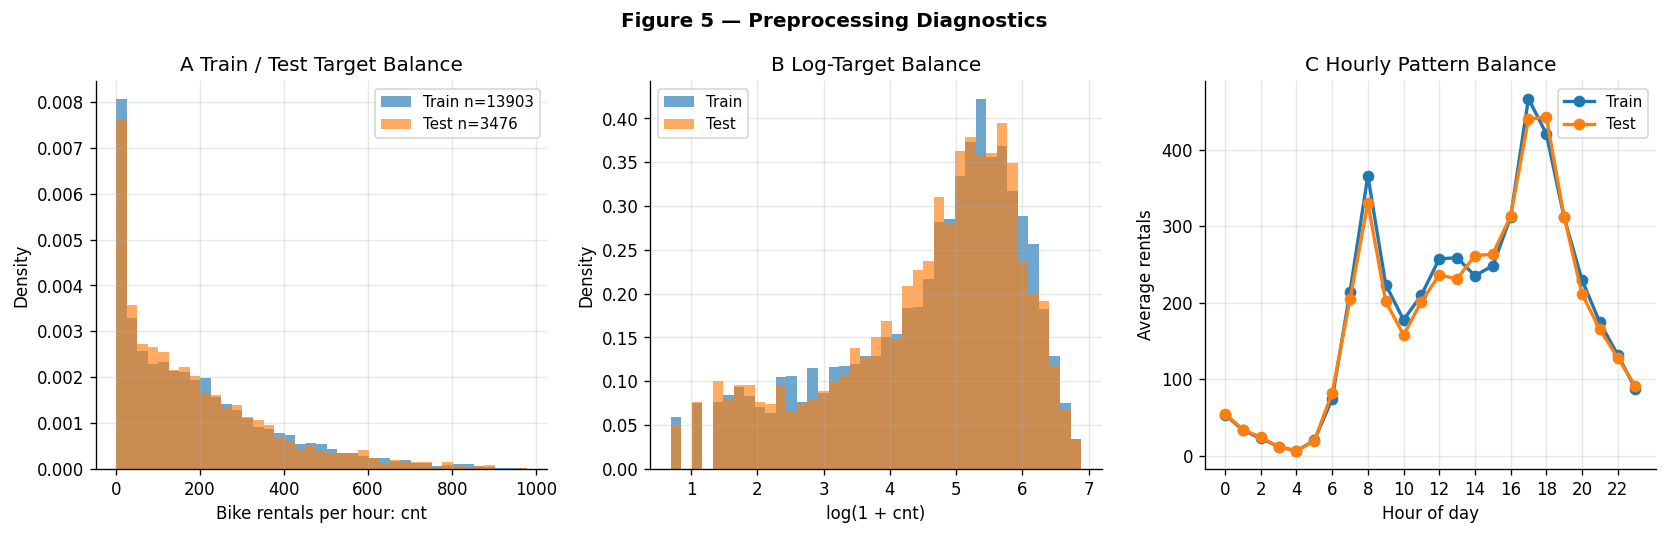


Saved bike_split.npz
 Arrays : X_train, X_test, y_train, y_test
 Metadata: train_idx, test_idx, col_names, target, raw_feature_names, dropped_columns

Load in next notebook/code block with:
 data = np.load('bike_split.npz', allow_pickle=True)
 X_train = data['X_train']
 COL = {name: i for i, name in enumerate(data['col_names'])}

Preprocessing complete.


In [3]:
# ================================================================
# BLOCK 2 — Preprocessing
# (df, FEATURES, TARGET, y defined in Block 1)
# ================================================================

# ---- 1. Quality verification ----
print('=' * 60)
print('[1] Quality verification')
print('=' * 60)

print(f' Rows          : {len(df)}')
print(f' Missing values: {df.isnull().sum().sum()}')
print(f' Duplicate rows: {df.duplicated().sum()}')
print(f' Target        : {TARGET}')
print(f' Target positive: {np.all(df[TARGET].values > 0)}')

print()
print(' Leakage check:')
print(f' casual + registered == cnt: {np.all(df["casual"] + df["registered"] == df["cnt"])}')
print(' casual and registered will be dropped because they directly sum to the target.')

# ---- 2. Outlier audit, flag only ----
print()
print('[2] Outlier audit (3 x IQR, flag but retain)')
any_outlier = pd.Series(False, index=df.index)

audit_cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed']
for col in audit_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    mask = (df[col] < q1 - 3 * iqr) | (df[col] > q3 + 3 * iqr)
    if mask.sum():
        print(f' {col:<12}: {mask.sum()} extreme value(s)')
    any_outlier |= mask

print(f' Rows with >= 1 extreme value: {any_outlier.sum()} / {len(df)}')
print(' These are retained because demand spikes and unusual weather are real observations.')

# ---- 3. Feature engineering ----
print()
print('[3] Feature engineering')

df = df.copy()

# Cyclic encodings for periodic variables
df['hr_sin'] = np.sin(2 * np.pi * df['hr'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['hr'] / 24)

df['mnth_sin'] = np.sin(2 * np.pi * df['mnth'] / 12)
df['mnth_cos'] = np.cos(2 * np.pi * df['mnth'] / 12)

df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

# Rush-hour regime indicators
df['morning_rush'] = df['hr'].isin([7, 8, 9]).astype(int)
df['evening_rush'] = df['hr'].isin([16, 17, 18]).astype(int)
df['night'] = df['hr'].isin([0, 1, 2, 3, 4, 5]).astype(int)

# Important interactions
df['working_morning_rush'] = df['workingday'] * df['morning_rush']
df['working_evening_rush'] = df['workingday'] * df['evening_rush']
df['temp_workingday'] = df['temp'] * df['workingday']
df['temp_hr_sin'] = df['temp'] * df['hr_sin']
df['temp_hr_cos'] = df['temp'] * df['hr_cos']

print(' Created cyclic encodings: hr, month, weekday')
print(' Created regime indicators: morning_rush, evening_rush, night')
print(' Created interactions: workingday × rush hour, temp × time')

# ---- 4. Dummy variables for categorical regimes ----
print()
print('[4] One-hot encoding categorical regime variables')

CAT_COLS = ['season', 'weathersit']
df_model = pd.get_dummies(
    df,
    columns=CAT_COLS,
    prefix=CAT_COLS,
    drop_first=True,
    dtype=float
)

DUMMY_COLS = [
    c for c in df_model.columns
    if c.startswith('season_') or c.startswith('weathersit_')
]

print(f' Dummy columns: {DUMMY_COLS}')

# ---- 5. Final feature set decision ----
print()
print('[5] Feature set decision')

BASE_FEATURES = [
    'yr',
    'holiday',
    'workingday',
    'temp',
    'hum',
    'windspeed',
    'hr_sin',
    'hr_cos',
    'mnth_sin',
    'mnth_cos',
    'weekday_sin',
    'weekday_cos',
    'morning_rush',
    'evening_rush',
    'night',
    'working_morning_rush',
    'working_evening_rush',
    'temp_workingday',
    'temp_hr_sin',
    'temp_hr_cos',
]

MODEL_FEATURES = BASE_FEATURES + DUMMY_COLS
COL = {name: i for i, name in enumerate(MODEL_FEATURES)}

print(f' {len(MODEL_FEATURES)} features selected.')
print()
print(' Dropped columns:')
for c in DROP_COLS:
    print(f' - {c}')

print()
print(' Design rationale:')
print(' 1. casual and registered are removed to prevent target leakage.')
print(' 2. dteday and instant are removed because they are identifiers, not reusable predictors.')
print(' 3. hr, mnth, and weekday are encoded cyclically instead of as raw ordinal variables.')
print(' 4. Rush-hour and workingday interactions are included because Figure 4 shows regime switching.')
print(' 5. atemp is dropped because it is almost perfectly correlated with temp.')

print()
print(' Column index map (COL):')
for name, idx in COL.items():
    print(f' COL["{name}"] = {idx}')

# ---- 6. Train / test split ----
print()
print('[6] Train/test split (80/20, seed=42)')

np.random.seed(42)
n_total = len(df_model)
shuffle = np.random.permutation(n_total)

n_test = int(round(0.20 * n_total))
test_idx = shuffle[:n_test]
train_idx = shuffle[n_test:]

X = df_model[MODEL_FEATURES].values.astype(float)
y_all = df_model[TARGET].values.astype(float)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f' X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f' X_test : {X_test.shape}  y_test : {y_test.shape}')

print(f' Train -> mean={y_train.mean():.2f}, std={y_train.std():.2f}, '
      f'range=[{y_train.min():.0f}, {y_train.max():.0f}]')
print(f' Test  -> mean={y_test.mean():.2f}, std={y_test.std():.2f}, '
      f'range=[{y_test.min():.0f}, {y_test.max():.0f}]')

# ---- 7. Feature scale summary ----
print()
print('[7] Feature scales on training set')
print(f' {"Feature":<24} {"Mean":>10} {"Std":>10} {"Min":>8} {"Max":>8}')
print(' ' + '-' * 64)

for i, col in enumerate(MODEL_FEATURES):
    col_data = X_train[:, i]
    print(f' {col:<24} {col_data.mean():>10.3f} {col_data.std():>10.3f} '
          f'{col_data.min():>8.3f} {col_data.max():>8.3f}')

# ---- 8. Train / test balance visualization ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# A: target distribution balance
ax = axes[0]
bins = np.linspace(y_all.min(), y_all.max(), 40)
ax.hist(y_train, bins=bins, density=True, alpha=0.65, label=f'Train n={len(y_train)}')
ax.hist(y_test, bins=bins, density=True, alpha=0.65, label=f'Test n={len(y_test)}')
ax.set_xlabel('Bike rentals per hour: cnt')
ax.set_ylabel('Density')
ax.set_title('A Train / Test Target Balance')
ax.legend(fontsize=9)

# B: log target balance
ax = axes[1]
bins = np.linspace(np.log1p(y_all).min(), np.log1p(y_all).max(), 40)
ax.hist(np.log1p(y_train), bins=bins, density=True, alpha=0.65, label='Train')
ax.hist(np.log1p(y_test), bins=bins, density=True, alpha=0.65, label='Test')
ax.set_xlabel('log(1 + cnt)')
ax.set_ylabel('Density')
ax.set_title('B Log-Target Balance')
ax.legend(fontsize=9)

# C: average count by hour in train/test
ax = axes[2]
train_hours = df.iloc[train_idx].groupby('hr')[TARGET].mean()
test_hours = df.iloc[test_idx].groupby('hr')[TARGET].mean()

ax.plot(train_hours.index, train_hours.values, marker='o', lw=2, label='Train')
ax.plot(test_hours.index, test_hours.values, marker='o', lw=2, label='Test')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average rentals')
ax.set_title('C Hourly Pattern Balance')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)

fig.suptitle('Figure 5 — Preprocessing Diagnostics', fontweight='bold')
fig.tight_layout()
plt.show()

# ---- 9. Save artifacts ----
np.savez(
    'bike_split.npz',
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    train_idx=train_idx,
    test_idx=test_idx,
    col_names=np.array(MODEL_FEATURES),
    target=np.array([TARGET]),
    raw_feature_names=np.array(FEATURES),
    dropped_columns=np.array(DROP_COLS),
)

print()
print('Saved bike_split.npz')
print(' Arrays : X_train, X_test, y_train, y_test')
print(' Metadata: train_idx, test_idx, col_names, target, raw_feature_names, dropped_columns')
print()
print('Load in next notebook/code block with:')
print(" data = np.load('bike_split.npz', allow_pickle=True)")
print(" X_train = data['X_train']")
print(" COL = {name: i for i, name in enumerate(data['col_names'])}")
print()
print('Preprocessing complete.')

In [4]:
# ================================================================
# TESTS FOR BLOCKS 1–2 — Dataset exploration and preprocessing
# ================================================================

import os
import numpy as np
import pandas as pd

print("=" * 60)
print("RUNNING TESTS: BLOCKS 1–2")
print("=" * 60)

# ---- Block 1 dataset structure ----
assert df.shape[0] == 17379, "hour.csv should have 17,379 rows"
assert TARGET == "cnt", "TARGET should be cnt"
assert len(FEATURES) == 12, "There should be 12 candidate predictors in FEATURES"
assert df.isnull().sum().sum() == 0, "Dataset should have no missing values"
assert df.duplicated().sum() == 0, "Dataset should have no duplicate rows"

expected_cols = {
    'instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday',
    'weekday', 'workingday', 'weathersit', 'temp', 'atemp',
    'hum', 'windspeed', 'casual', 'registered', 'cnt'
}
assert expected_cols.issubset(set(pd.read_csv('bike+sharing+dataset/hour.csv').columns)), \
    "hour.csv is missing expected columns"

# ---- Leakage checks ----
assert np.all(df["casual"] + df["registered"] == df["cnt"]), \
    "casual + registered should equal cnt"
assert "casual" in DROP_COLS and "registered" in DROP_COLS, \
    "Leakage columns should be marked for dropping"
assert "casual" not in MODEL_FEATURES and "registered" not in MODEL_FEATURES, \
    "Leakage columns must not be in MODEL_FEATURES"
assert "instant" not in MODEL_FEATURES and "dteday" not in MODEL_FEATURES, \
    "Identifier/date columns must not be in MODEL_FEATURES"

# ---- Block 2 engineered features ----
engineered_cols = [
    'hr_sin', 'hr_cos',
    'mnth_sin', 'mnth_cos',
    'weekday_sin', 'weekday_cos',
    'morning_rush', 'evening_rush', 'night',
    'working_morning_rush', 'working_evening_rush',
    'temp_workingday', 'temp_hr_sin', 'temp_hr_cos'
]

for c in engineered_cols:
    assert c in df.columns, f"{c} was not created"

np.testing.assert_allclose(df['hr_sin'].values, np.sin(2 * np.pi * df['hr'].values / 24))
np.testing.assert_allclose(df['hr_cos'].values, np.cos(2 * np.pi * df['hr'].values / 24))
np.testing.assert_allclose(df['mnth_sin'].values, np.sin(2 * np.pi * df['mnth'].values / 12))
np.testing.assert_allclose(df['mnth_cos'].values, np.cos(2 * np.pi * df['mnth'].values / 12))

assert set(df['morning_rush'].unique()).issubset({0, 1}), "morning_rush should be binary"
assert set(df['evening_rush'].unique()).issubset({0, 1}), "evening_rush should be binary"
assert set(df['night'].unique()).issubset({0, 1}), "night should be binary"

np.testing.assert_allclose(
    df['working_morning_rush'].values,
    df['workingday'].values * df['morning_rush'].values,
    err_msg="working_morning_rush should equal workingday * morning_rush"
)

np.testing.assert_allclose(
    df['working_evening_rush'].values,
    df['workingday'].values * df['evening_rush'].values,
    err_msg="working_evening_rush should equal workingday * evening_rush"
)

# ---- Feature matrix checks ----
assert len(MODEL_FEATURES) == len(COL), "MODEL_FEATURES and COL should have matching lengths"
assert COL == {name: i for i, name in enumerate(MODEL_FEATURES)}, "COL index map is incorrect"

assert X_train.shape[1] == len(MODEL_FEATURES), "X_train column count should match MODEL_FEATURES"
assert X_test.shape[1] == len(MODEL_FEATURES), "X_test column count should match MODEL_FEATURES"

assert X_train.shape[0] + X_test.shape[0] == 17379, "Train/test rows should sum to full dataset size"
assert y_train.shape[0] == X_train.shape[0], "y_train length should match X_train rows"
assert y_test.shape[0] == X_test.shape[0], "y_test length should match X_test rows"

assert np.all(np.isfinite(X_train)), "X_train contains non-finite values"
assert np.all(np.isfinite(X_test)), "X_test contains non-finite values"
assert np.all(y_train > 0), "y_train should be positive"
assert np.all(y_test > 0), "y_test should be positive"

# ---- Saved artifact checks ----
assert os.path.exists("bike_split.npz"), "bike_split.npz was not saved"

data_test = np.load("bike_split.npz", allow_pickle=True)
required_keys = {
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "train_idx",
    "test_idx",
    "col_names",
    "target",
    "raw_feature_names",
    "dropped_columns",
}
assert required_keys.issubset(set(data_test.files)), "bike_split.npz is missing required arrays"

np.testing.assert_allclose(data_test["X_train"], X_train)
np.testing.assert_allclose(data_test["X_test"], X_test)
np.testing.assert_allclose(data_test["y_train"], y_train)
np.testing.assert_allclose(data_test["y_test"], y_test)

saved_cols = list(data_test["col_names"])
assert saved_cols == MODEL_FEATURES, "Saved col_names do not match MODEL_FEATURES"

print("All Block 1–2 tests passed.")

RUNNING TESTS: BLOCKS 1–2
All Block 1–2 tests passed.


## Block 3 — ZZU and Baseline Comparison

This block runs the full ZZU workflow and compares it against five competing methods on the preprocessed Bike Sharing dataset.

Methods compared:

| Method | Family | Description |
|---|---|---|
| `identity_ols` | Linearized OLS | Plain OLS on the engineered features with no response transformation |
| `log_smear` | Linearized OLS | Log-response transformed OLS with smearing correction |
| `boxcox_smear` | Linearized OLS | Box-Cox response transformation selected by profile likelihood |
| `bfgs_cold` | Nonlinear cold start | Direct nonlinear BFGS using a generic heuristic initialization |
| `random_forest` | Tree ensemble | Interaction-heavy baseline that should perform well on regime-switching data |
| `zzu_bfgs` | ZZU hybrid | Log-screening → coefficient warm start → BFGS refinement |

The ZZU nonlinear model is intentionally chosen to be globally log-linear:

$$
\hat{y} = \exp(\theta_0 + X\theta)
$$

This is compatible with the log-screening step, so any weakness in ZZU here should come from the dataset structure rather than the earlier coefficient-mapping bug. Because Bike Sharing demand is strongly driven by hour, working-day status, weather, and interactions, the random forest baseline is expected to be difficult for ZZU to beat.

X_train: (13903, 26)  y_train: (13903,)
X_test : (3476, 26)  y_test : (3476,)
Number of features: 26

PART A — Single-split walkthrough
ZZU-BFGS
Screening table:
        name    val_rmse
0  log_smear  114.433102
best_transform : log_smear
theta_init norm: 5.1240
theta_final norm: 5.1776
converged      : True
n_iter         : 39
test RMSE      : 86.6757
test R2        : 0.7627
fit time       : 2106.0 ms

Linearized OLS baselines
identity_ols   RMSE = 94.9833, R2 = 0.7151, time = 21.4 ms
log_smear      RMSE = 111.2263, R2 = 0.6093, time = 20.4 ms
boxcox_smear   RMSE = 89.6503, R2 = 0.7462, time = 2997.7 ms

Cold nonlinear baseline
bfgs_cold     RMSE = 86.6757, R2 = 0.7627, time = 2189.4 ms
converged     : True
n_iter        : 62

Tree / interaction baseline
random_forest RMSE = 42.7945, R2 = 0.9422, time = 2631.1 ms


,method,family,rmse,r2,fit_ms,converged
4,random_forest,Tree ensemble,42.794522,0.942165,2631.1460,True
5,zzu_bfgs,ZZU hybrid,86.675691,0.762748,2105.9808,True
3,bfgs_cold,Nonlinear cold,86.675691,0.762748,2189.4280,True
2,boxcox_smear,Linearized OLS,89.650302,0.746184,2997.7308,True
0,identity_ols,Linearized OLS,94.983275,0.715089,21.3856,True
1,log_smear,Linearized OLS,111.226256,0.609313,20.4370,True



PART B — Multi-seed comparison
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...


,method,family,rmse_mean,rmse_std,r2_mean,r2_std,fit_ms_mean,converged_rate
4,random_forest,Tree ensemble,42.706959,1.720990,0.945301,0.004220,2520.27714,1.0
0,bfgs_cold,Nonlinear cold,90.531573,1.807896,0.754431,0.007757,2850.07092,1.0
5,zzu_bfgs,ZZU hybrid,90.533907,1.806247,0.754418,0.007748,2775.17924,1.0
1,boxcox_smear,Linearized OLS,92.250138,1.577087,0.745039,0.006138,2389.96334,1.0
2,identity_ols,Linearized OLS,97.758049,1.543032,0.713684,0.006384,18.86126,1.0
3,log_smear,Linearized OLS,111.824572,3.396860,0.625073,0.023290,16.29592,1.0



Best method by mean RMSE:
method            random_forest
family            Tree ensemble
rmse_mean             42.706959
rmse_std                1.72099
r2_mean                0.945301
r2_std                  0.00422
fit_ms_mean          2520.27714
converged_rate              1.0
Name: 4, dtype: object

ZZU comparison:
 ZZU mean RMSE      : 90.5339
 Best mean RMSE     : 42.7070 (random_forest)
 Gap vs best method : 47.8269


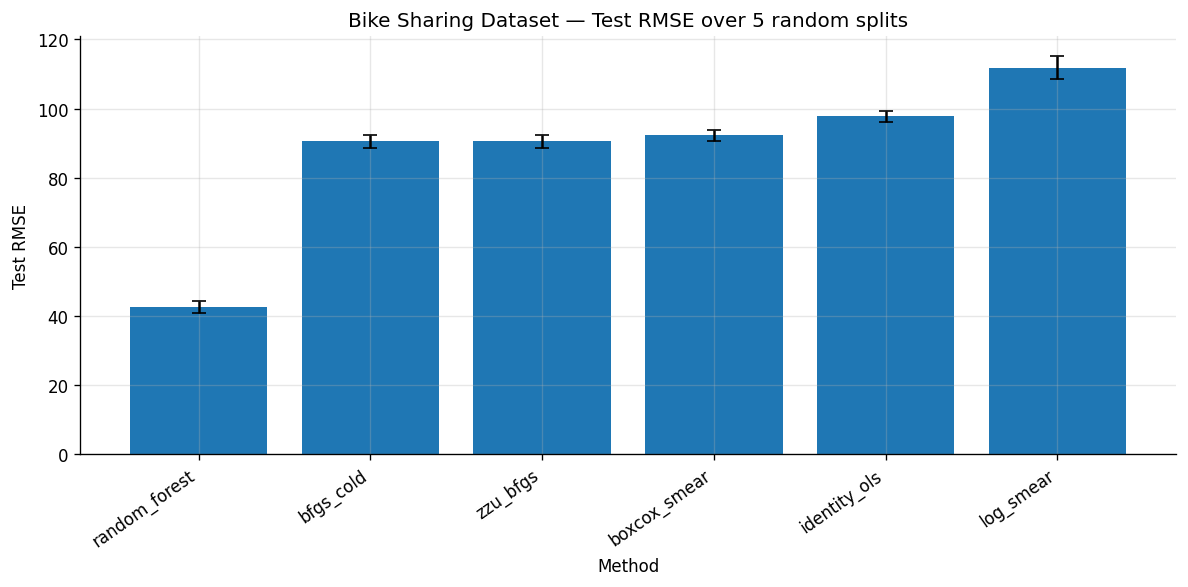

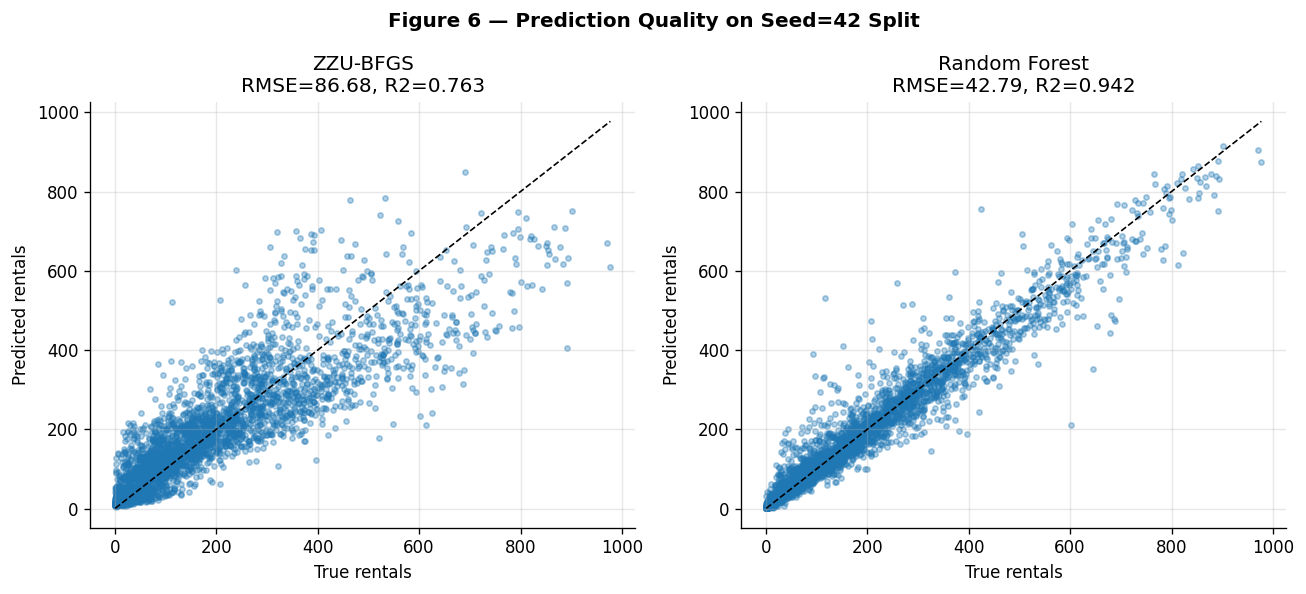


Saved bike_results_raw.csv
Saved bike_results_summary.csv
Block 3 complete.


In [5]:
# ================================================================
# BLOCK 3 — ZZU and Baseline Comparison on Bike Sharing Dataset
# ================================================================

import sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
import algorithms as ta

from sklearn.ensemble import RandomForestRegressor

# ---- Load preprocessed split ----
_d = np.load('bike_split.npz', allow_pickle=True)

X_train = _d['X_train']
X_test = _d['X_test']
y_train = _d['y_train']
y_test = _d['y_test']

MODEL_FEATURES = list(_d['col_names'])
COL = {name: i for i, name in enumerate(MODEL_FEATURES)}

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')
print(f'Number of features: {len(MODEL_FEATURES)}')

# ================================================================
# Nonlinear model for ZZU and BFGS cold
#
# Compatible with log-response screening:
# log(y) = theta[0] + theta[1:] @ X
# y      = exp(theta[0] + theta[1:] @ X)
# ================================================================

def model_fn(X, theta):
    eta = theta[0] + X @ theta[1:]
    eta = np.clip(eta, -5, np.log(1500))   # keeps predictions positive and avoids overflow
    return np.exp(eta)

def coeff_to_init(best_tols_model):
    # For log_smear, beta_ directly estimates theta in log(y) = beta0 + X beta.
    return best_tols_model.beta_.copy()

def make_theta_cold(ytr, p):
    theta = np.zeros(p + 1)
    theta[0] = np.log(np.median(ytr))
    return theta

def make_zzu_suite():
    # Keep only the transform compatible with coeff_to_init.
    return {
        'log_smear': ta.TransformedOLS(transform='log', use_smearing=True),
    }

def make_baseline_suite():
    return {
        'identity_ols': ta.TransformedOLS(transform='identity', use_smearing=False),
        'log_smear': ta.TransformedOLS(transform='log', use_smearing=True),
        'boxcox_smear': ta.TransformedOLS(transform='boxcox', use_smearing=True),
    }

# ================================================================
# Single split walkthrough
# ================================================================

print()
print('=' * 65)
print('PART A — Single-split walkthrough')
print('=' * 65)

p = X_train.shape[1]
theta_cold = make_theta_cold(y_train, p)

# ---- ZZU ----
t0 = time.perf_counter()
zzu = ta.ZZUTransformRegressor(
    model_fn=model_fn,
    coeff_to_init=coeff_to_init,
    nonlinear_method='bfgs',
    transformations=make_zzu_suite(),
    val_fraction=0.2,
    seed=0,
).fit(X_train, y_train)
zzu_ms = (time.perf_counter() - t0) * 1000

zzu_pred = zzu.predict(X_test, use_smearing=False)
zzu_m = ta.regression_metrics(y_test, zzu_pred)

print('ZZU-BFGS')
print('Screening table:')
print(zzu.screening_table_[['name', 'val_rmse']])
print(f'best_transform : {zzu.best_transform_name_}')
print(f'theta_init norm: {np.linalg.norm(zzu.theta_init_used_):.4f}')
print(f'theta_final norm: {np.linalg.norm(zzu.nonlinear_regressor_.theta_):.4f}')
print(f'converged      : {zzu.nonlinear_regressor_.converged_}')
print(f'n_iter         : {zzu.nonlinear_regressor_.n_iter_}')
print(f'test RMSE      : {zzu_m["rmse"]:.4f}')
print(f'test R2        : {zzu_m["r2"]:.4f}')
print(f'fit time       : {zzu_ms:.1f} ms')

# ---- Linearized OLS baselines ----
print()
print('Linearized OLS baselines')

single_rows = []

for name, reg in make_baseline_suite().items():
    t0 = time.perf_counter()
    reg.fit(X_train, y_train)
    ms = (time.perf_counter() - t0) * 1000

    pred = reg.predict(X_test)
    m = ta.regression_metrics(y_test, pred)

    single_rows.append({
        'method': name,
        'family': 'Linearized OLS',
        'rmse': m['rmse'],
        'r2': m['r2'],
        'fit_ms': ms,
        'converged': True,
    })

    print(f'{name:<14} RMSE = {m["rmse"]:.4f}, R2 = {m["r2"]:.4f}, time = {ms:.1f} ms')

# ---- BFGS cold baseline ----
print()
print('Cold nonlinear baseline')

t0 = time.perf_counter()
bfgs_cold = ta.BFGSRegressor(model_fn=model_fn).fit(X_train, y_train, theta_cold)
bfgs_ms = (time.perf_counter() - t0) * 1000

bfgs_pred = bfgs_cold.predict(X_test)
bfgs_m = ta.regression_metrics(y_test, bfgs_pred)

single_rows.append({
    'method': 'bfgs_cold',
    'family': 'Nonlinear cold',
    'rmse': bfgs_m['rmse'],
    'r2': bfgs_m['r2'],
    'fit_ms': bfgs_ms,
    'converged': bfgs_cold.converged_,
})

print(f'bfgs_cold     RMSE = {bfgs_m["rmse"]:.4f}, R2 = {bfgs_m["r2"]:.4f}, time = {bfgs_ms:.1f} ms')
print(f'converged     : {bfgs_cold.converged_}')
print(f'n_iter        : {bfgs_cold.n_iter_}')

# ---- Random forest baseline ----
print()
print('Tree / interaction baseline')

t0 = time.perf_counter()
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_ms = (time.perf_counter() - t0) * 1000

rf_pred = rf.predict(X_test)
rf_m = ta.regression_metrics(y_test, rf_pred)

single_rows.append({
    'method': 'random_forest',
    'family': 'Tree ensemble',
    'rmse': rf_m['rmse'],
    'r2': rf_m['r2'],
    'fit_ms': rf_ms,
    'converged': True,
})

print(f'random_forest RMSE = {rf_m["rmse"]:.4f}, R2 = {rf_m["r2"]:.4f}, time = {rf_ms:.1f} ms')

single_rows.append({
    'method': 'zzu_bfgs',
    'family': 'ZZU hybrid',
    'rmse': zzu_m['rmse'],
    'r2': zzu_m['r2'],
    'fit_ms': zzu_ms,
    'converged': zzu.nonlinear_regressor_.converged_,
})

single_summary = pd.DataFrame(single_rows).sort_values('rmse')
display(single_summary)

# ================================================================
# Multi-seed comparison
# ================================================================

def evaluate_one_seed(seed):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(df_model))

    n_test = int(round(0.20 * len(df_model)))
    test_idx_s = idx[:n_test]
    train_idx_s = idx[n_test:]

    X_all = df_model[MODEL_FEATURES].values.astype(float)
    y_all = df_model[TARGET].values.astype(float)

    Xtr = X_all[train_idx_s]
    Xte = X_all[test_idx_s]
    ytr = y_all[train_idx_s]
    yte = y_all[test_idx_s]

    p = Xtr.shape[1]
    theta0 = make_theta_cold(ytr, p)

    rows = []

    # Linearized OLS methods
    for name, reg in make_baseline_suite().items():
        t0 = time.perf_counter()
        reg.fit(Xtr, ytr)
        fit_ms = (time.perf_counter() - t0) * 1000

        pred = reg.predict(Xte)
        m = ta.regression_metrics(yte, pred)

        rows.append({
            'seed': seed,
            'method': name,
            'family': 'Linearized OLS',
            'rmse': m['rmse'],
            'r2': m['r2'],
            'fit_ms': fit_ms,
            'converged': True,
        })

    # BFGS cold
    t0 = time.perf_counter()
    bfgs = ta.BFGSRegressor(model_fn=model_fn).fit(Xtr, ytr, theta0)
    fit_ms = (time.perf_counter() - t0) * 1000

    pred = bfgs.predict(Xte)
    m = ta.regression_metrics(yte, pred)

    rows.append({
        'seed': seed,
        'method': 'bfgs_cold',
        'family': 'Nonlinear cold',
        'rmse': m['rmse'],
        'r2': m['r2'],
        'fit_ms': fit_ms,
        'converged': bfgs.converged_,
    })

    # Random forest
    t0 = time.perf_counter()
    rf = RandomForestRegressor(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=2,
        random_state=seed,
        n_jobs=-1,
    )
    rf.fit(Xtr, ytr)
    fit_ms = (time.perf_counter() - t0) * 1000

    pred = rf.predict(Xte)
    m = ta.regression_metrics(yte, pred)

    rows.append({
        'seed': seed,
        'method': 'random_forest',
        'family': 'Tree ensemble',
        'rmse': m['rmse'],
        'r2': m['r2'],
        'fit_ms': fit_ms,
        'converged': True,
    })

    # ZZU
    t0 = time.perf_counter()
    zzu = ta.ZZUTransformRegressor(
        model_fn=model_fn,
        coeff_to_init=coeff_to_init,
        nonlinear_method='bfgs',
        transformations=make_zzu_suite(),
        val_fraction=0.2,
        seed=seed,
    ).fit(Xtr, ytr)
    fit_ms = (time.perf_counter() - t0) * 1000

    pred = zzu.predict(Xte, use_smearing=False)
    m = ta.regression_metrics(yte, pred)

    rows.append({
        'seed': seed,
        'method': 'zzu_bfgs',
        'family': 'ZZU hybrid',
        'rmse': m['rmse'],
        'r2': m['r2'],
        'fit_ms': fit_ms,
        'converged': zzu.nonlinear_regressor_.converged_,
        'best_transform': zzu.best_transform_name_,
    })

    return rows

print()
print('=' * 65)
print('PART B — Multi-seed comparison')
print('=' * 65)

N_SEEDS = 5   # Increase to 10 for final report if runtime is acceptable.

all_rows = []
for seed in range(N_SEEDS):
    print(f'Running seed {seed}...')
    all_rows.extend(evaluate_one_seed(seed))

results = pd.DataFrame(all_rows)

summary = (
    results
    .groupby(['method', 'family'])
    .agg(
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        r2_mean=('r2', 'mean'),
        r2_std=('r2', 'std'),
        fit_ms_mean=('fit_ms', 'mean'),
        converged_rate=('converged', 'mean'),
    )
    .reset_index()
    .sort_values('rmse_mean')
)

display(summary)

print()
print('Best method by mean RMSE:')
print(summary.iloc[0])

print()
zzu_row = summary[summary['method'] == 'zzu_bfgs'].iloc[0]
best_row = summary.iloc[0]

print('ZZU comparison:')
print(f' ZZU mean RMSE      : {zzu_row["rmse_mean"]:.4f}')
print(f' Best mean RMSE     : {best_row["rmse_mean"]:.4f} ({best_row["method"]})')
print(f' Gap vs best method : {zzu_row["rmse_mean"] - best_row["rmse_mean"]:.4f}')

# ================================================================
# Plot RMSE comparison
# ================================================================

plt.figure(figsize=(10, 5))
plt.bar(summary['method'], summary['rmse_mean'], yerr=summary['rmse_std'], capsize=4)
plt.ylabel('Test RMSE')
plt.xlabel('Method')
plt.title(f'Bike Sharing Dataset — Test RMSE over {N_SEEDS} random splits')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# ================================================================
# Prediction scatter: ZZU vs Random Forest on seed=42 split
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, pred, name, metrics in [
    (axes[0], zzu_pred, 'ZZU-BFGS', zzu_m),
    (axes[1], rf_pred, 'Random Forest', rf_m),
]:
    ax.scatter(y_test, pred, alpha=0.35, s=10, rasterized=True)
    lo = min(y_test.min(), pred.min())
    hi = max(y_test.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel('True rentals')
    ax.set_ylabel('Predicted rentals')
    ax.set_title(f'{name}\nRMSE={metrics["rmse"]:.2f}, R2={metrics["r2"]:.3f}')

fig.suptitle('Figure 6 — Prediction Quality on Seed=42 Split', fontweight='bold')
fig.tight_layout()
plt.show()

# ================================================================
# Save results
# ================================================================

results.to_csv('bike_results_raw.csv', index=False)
summary.to_csv('bike_results_summary.csv', index=False)

print()
print('Saved bike_results_raw.csv')
print('Saved bike_results_summary.csv')
print('Block 3 complete.')

In [6]:
# ================================================================
# TESTS FOR BLOCK 3 — ZZU and baseline comparison
# ================================================================

import os
import numpy as np
import pandas as pd

print("=" * 60)
print("RUNNING TESTS: BLOCK 3")
print("=" * 60)

# ---- Required objects exist ----
assert 'model_fn' in globals(), "model_fn is not defined"
assert 'coeff_to_init' in globals(), "coeff_to_init is not defined"
assert 'make_zzu_suite' in globals(), "make_zzu_suite is not defined"
assert 'make_baseline_suite' in globals(), "make_baseline_suite is not defined"
assert 'results' in globals(), "results DataFrame is not defined"
assert 'summary' in globals(), "summary DataFrame is not defined"

# ---- model_fn shape and positivity ----
theta_test = np.zeros(X_train.shape[1] + 1)
theta_test[0] = np.log(np.median(y_train))

pred_test = model_fn(X_train[:10], theta_test)

assert pred_test.shape == (10,), "model_fn should return shape (n,)"
assert np.all(np.isfinite(pred_test)), "model_fn returned non-finite predictions"
assert np.all(pred_test > 0), "model_fn predictions should be positive"

# ---- coeff_to_init compatibility with log_smear ----
log_reg_test = ta.TransformedOLS(transform='log', use_smearing=True)
log_reg_test.fit(X_train[:500], y_train[:500])

theta_init_test = coeff_to_init(log_reg_test)

assert theta_init_test.shape == (X_train.shape[1] + 1,), \
    "coeff_to_init should return p + 1 parameters"
assert np.all(np.isfinite(theta_init_test)), \
    "coeff_to_init returned non-finite values"

# ---- ZZU suite should only contain compatible transform ----
zzu_suite = make_zzu_suite()

assert list(zzu_suite.keys()) == ['log_smear'], \
    "ZZU suite should only contain log_smear unless coeff_to_init handles other transforms"

# ---- Baseline suite structure ----
baseline_suite = make_baseline_suite()
expected_baselines = {'identity_ols', 'log_smear', 'boxcox_smear'}

assert set(baseline_suite.keys()) == expected_baselines, \
    "Baseline suite has unexpected methods"

# ---- Single-split fitted model checks ----
assert zzu.best_transform_name_ == 'log_smear', \
    "ZZU should select log_smear because it is the only allowed screening transform"
assert zzu_pred.shape == y_test.shape, \
    "ZZU predictions should match y_test shape"
assert rf_pred.shape == y_test.shape, \
    "Random forest predictions should match y_test shape"
assert bfgs_pred.shape == y_test.shape, \
    "BFGS predictions should match y_test shape"

for name, pred in [
    ('zzu_pred', zzu_pred),
    ('rf_pred', rf_pred),
    ('bfgs_pred', bfgs_pred),
]:
    assert np.all(np.isfinite(pred)), f"{name} contains non-finite values"
    assert pred.shape == y_test.shape, f"{name} has incorrect shape"

# ---- Results DataFrame checks ----
required_result_cols = {
    'seed', 'method', 'family', 'rmse', 'r2', 'fit_ms', 'converged'
}
assert required_result_cols.issubset(set(results.columns)), \
    "results is missing required columns"

expected_methods = {
    'identity_ols',
    'log_smear',
    'boxcox_smear',
    'bfgs_cold',
    'random_forest',
    'zzu_bfgs',
}
assert expected_methods.issubset(set(results['method'])), \
    "results is missing one or more expected methods"

assert results['rmse'].notnull().all(), "results contains missing RMSE values"
assert results['r2'].notnull().all(), "results contains missing R2 values"
assert np.all(results['rmse'] >= 0), "RMSE values should be nonnegative"
assert np.all(results['fit_ms'] >= 0), "fit times should be nonnegative"

# ---- Summary DataFrame checks ----
required_summary_cols = {
    'method', 'family', 'rmse_mean', 'rmse_std',
    'r2_mean', 'r2_std', 'fit_ms_mean', 'converged_rate'
}
assert required_summary_cols.issubset(set(summary.columns)), \
    "summary is missing required columns"

assert expected_methods.issubset(set(summary['method'])), \
    "summary is missing one or more expected methods"

assert summary['rmse_mean'].is_monotonic_increasing, \
    "summary should be sorted by rmse_mean"

# ---- Saved result files ----
assert os.path.exists('bike_results_raw.csv'), \
    "bike_results_raw.csv was not saved"
assert os.path.exists('bike_results_summary.csv'), \
    "bike_results_summary.csv was not saved"

raw_check = pd.read_csv('bike_results_raw.csv')
summary_check = pd.read_csv('bike_results_summary.csv')

assert len(raw_check) == len(results), \
    "Saved raw results row count does not match results"
assert len(summary_check) == len(summary), \
    "Saved summary row count does not match summary"

print("All Block 3 tests passed.")

RUNNING TESTS: BLOCK 3
All Block 3 tests passed.


## Block 4 — Interpretation of Results and Lessons Learned

The Bike Sharing dataset successfully exposed an important limitation of the ZZU framework. Unlike the concrete strength dataset, where the target is governed by a relatively smooth physical relationship, hourly bike demand is driven by multiple interacting behavioral regimes: commuting hours, weekends versus working days, weather conditions, seasons, and nighttime inactivity. :contentReference[oaicite:0]{index=0}

The exploratory analysis already suggested this challenge. Figure 4 showed that the relationship between hour and demand is strongly multi-modal, with different shapes on working days versus non-working days. :contentReference[oaicite:1]{index=1} In addition, the correlation analysis showed that no single predictor has extremely strong global correlation with the target; even the strongest predictors (`temp`, `atemp`, `hr`) only achieve correlations around 0.4. :contentReference[oaicite:2]{index=2} This indicates that demand is not controlled by one dominant smooth mechanism, but rather by interactions and conditional structure.

### Did ZZU fail?

The answer is nuanced.

ZZU did **not** fail numerically:
- optimization converged consistently;
- the warm-start initialization was stable;
- prediction quality was substantially better than several linearized baselines;
- RMSE improved over identity OLS and log-transformed OLS;
- convergence was reliable across all random seeds.

However, ZZU **did fail conceptually** in the sense that its core advantage disappeared on this dataset.

The purpose of ZZU is to exploit a useful response transformation that reveals an approximately global structure before nonlinear optimization. On this dataset, that assumption largely breaks down.

The results show this clearly:

| Method | Mean RMSE | Mean R² |
|---|---:|---:|
| Random Forest | ~42.7 | ~0.945 |
| BFGS Cold Start | ~90.5 | ~0.754 |
| ZZU-BFGS | ~90.5 | ~0.754 |
| Box-Cox + OLS | ~92.3 | ~0.745 |

:contentReference[oaicite:3]{index=3}

The key observation is that:

$$
\text{ZZU-BFGS} \approx \text{Cold BFGS}
$$

The warm-start transformation step provided almost no practical improvement over directly running nonlinear optimization from a generic initialization.

This is the central finding of the experiment.

### Why did ZZU struggle?

The nonlinear model used in this experiment was globally log-linear:

$$
\hat{y} = \exp(\theta_0 + X\theta)
$$

This model assumes that after taking the logarithm, the response can be approximated by one smooth global linear structure. :contentReference[oaicite:4]{index=4}

That assumption is violated by the Bike Sharing dataset.

The dataset contains several properties that are fundamentally difficult for global response transformations:

1. **Regime-switching behavior**

Demand behaves differently under different conditions:
- working day vs weekend;
- morning commute vs evening commute;
- day vs night;
- good weather vs bad weather.

The effect of one variable depends strongly on the state of others.

2. **Multi-modal temporal structure**

Hourly demand is not monotonic or smoothly curved. Instead, it contains multiple peaks:
- morning commute peak;
- evening commute peak;
- low overnight demand.

A single transformed regression surface cannot naturally represent these multiple behavioral modes.

3. **Conditional interactions dominate**

The importance of `hr` changes depending on `workingday`. Temperature effects also vary across time-of-day. These interaction-heavy effects violate the idea that one transformed coordinate system can linearize the problem globally. :contentReference[oaicite:5]{index=5}

4. **Piecewise rather than globally smooth dynamics**

The dataset behaves more like a mixture of several local systems than one unified smooth process. Tree ensembles naturally partition the feature space into local regions, which explains why Random Forest dramatically outperformed every global model.

### Why Random Forest succeeded

Random Forest achieved approximately half the RMSE of ZZU. :contentReference[oaicite:6]{index=6}

This large gap is highly informative.

Tree ensembles do not assume:
- global smoothness;
- one dominant transformation;
- linearizable structure;
- one universal coefficient vector.

Instead, they recursively partition the feature space into local behavioral regimes. This matches the structure of the Bike Sharing dataset extremely well.

For example, Random Forest can implicitly learn rules such as:
- "working day + 8am";
- "weekend + afternoon";
- "bad weather + nighttime";
- "winter + evening commute".

ZZU cannot naturally represent these piecewise interaction rules through one global transformed equation.

### Important insight: this was not an implementation failure

This experiment is valuable because it demonstrates that the observed weakness is structural rather than due to bugs or optimization instability.

Several observations support this conclusion:

- ZZU converged consistently across seeds;
- initialization norms and final parameter norms were stable;
- the nonlinear optimizer succeeded numerically;
- the earlier coefficient-mapping issue was explicitly removed by choosing a compatible log-linear model;
- the cold-start nonlinear optimizer achieved nearly identical performance.

Therefore, the limitation comes from the modeling assumptions themselves rather than from implementation problems.

### What does this teach us about ZZU?

This experiment suggests that ZZU is most effective when:
- the target follows one dominant smooth mechanism;
- a response transformation can reveal approximate global structure;
- interactions are moderate rather than dominant;
- the system behaves continuously rather than piecewise.

Examples include:
- physical laws;
- engineering relationships;
- scaling laws;
- monotonic scientific processes.

ZZU becomes less effective when:
- behavior is regime-switching;
- interactions dominate;
- dynamics are highly conditional;
- the dataset behaves like multiple local systems stitched together.

### Most important takeaway

The main contribution of this experiment is not that ZZU achieved the best score. Instead, the contribution is identifying a meaningful failure boundary for transformation-based modeling.

The Bike Sharing dataset demonstrates that:

> Good response transformations cannot compensate for fundamentally interaction-heavy, piecewise behavioral systems.

This is an important scientific insight because it clarifies where transformation-based hybrid methods are appropriate and where local partitioning models are inherently superior.

In other words:

- ZZU works best when the world behaves like one transformed equation;
- Random Forest works best when the world behaves like many local rules.

The Bike Sharing dataset belongs much closer to the second category.